# Sprint 9: Valida Hipotesis de Negocio con pruebas estadísticas

## 🎯 Objetivo de la sesión

1. **Construir e interpretar** una **tabla de contingencia** para dos variables categóricas en Python (`pd.crosstab`).
2. **Plantear correctamente** la pregunta de negocio, **H0/H1**, el **nivel de significancia (α)** y la interpretación del **p-valor**.
3. **Aplicar la prueba χ² de independencia** e interpretar:
   - estadístico χ²
   - **grados de libertad (df)**
   - **frecuencias esperadas**
4. **Verificar supuestos** de χ²:
   - **independencia** de observaciones
   - **frecuencias esperadas** (conteos suficientemente grandes)
5. **Decidir qué hacer** cuando los supuestos no se cumplen:
   - combinar categorías / agrupar niveles raros
   - usar **Fisher (2x2)** cuando hay conteos pequeños
6. **Cuantificar la fuerza de asociación** con **V de Cramér** y diferenciar:
   - “significativo” (p pequeño) vs “relevante” (efecto grande)
7. **Elegir y construir visualizaciones** para variables categóricas:
   - barras **agrupadas** vs **apiladas**
   - cuándo usar cada una para responder preguntas de negocio
8. **Resolver un caso aplicado** con el dataset dado:
   - en clase: **Device vs Conversion**
   - práctica: **Location vs Conversion** (χ² + V + gráficos)

---

## Miniagenda
1. **Warm up**
2. **Revisión Teórica**
6. **Ejercicio guiado:** Device vs Conversion completo.
7. **Reto del estudiante (tarea en clase o cierre):** Location vs Conversion + conclusión escrita (3–4 líneas).

# Revisión Teórica: # Relación entre variables categóricas: Tabla de contingencia, Chi-cuadrado y V de Cramér

## Tabla de contingencia (contingency table)
Una **tabla de contingencia** cruza dos variables categóricas y cuenta cuántas observaciones caen en cada combinación de categorías.

- Filas: categorías de la variable A  
- Columnas: categorías de la variable B  
- Celdas: **frecuencias observadas** (conteos reales)

En negocio, típicamente cruza cosas como:
- *Segmento (Bronce/Plata/Oro)* vs *Churn (Sí/No)*
- *Canal (Email/Ads/Orgánico)* vs *Compra (Sí/No)*
- *Región* vs *Tipo de plan*

---

## Prueba Chi-cuadrado de independencia (χ²)
### Pregunta típica

> ¿Existe **asociación** entre la variable A y la variable B?

### Hipótesis
- **H0 (nula):** No hay asociación entre A y B (Son independientes)
- **H1 (alternativa):** Sí hay asociación entre A y B (**no** son independientes)

### ¿Qué hace la prueba?
Compara:
- **Frecuencias observadas** (lo que pasó) vs
- **Frecuencias esperadas** (lo que *esperaríamos* si fueran independientes)

#### Frecuencias esperadas (Expected counts)
Si H0 fuera cierta, el conteo esperado en la celda (i,j) sería:

$$
E_{ij}=\frac{(\text{total fila i}) (\text{total columna j})}{n}
$$

### Grados de libertad (degrees of freedom, df)
Miden cuánta “libertad” tiene la tabla para variar una vez fijas los totales por fila y columna.

Para una tabla de r filas y c columnas:

$$
df=(r-1)(c-1)
$$

### p-valor e “importancia estadística”
- El **p-valor** es la probabilidad de observar la discrepancia Observado vs Esperado  **si H0 fuera cierta**.
- Si **p < α** (por ejemplo, 0.05) → rechazamos H0 → decimos que la asociación es **estadísticamente significativa**.

⚠️ Importante: “significativa” ≠ “grande” o “útil”. Con muchos datos puedes tener p pequeña con un efecto minúsculo.

---

## 3) Tamaño del efecto: V de Cramér
La χ² te dice *si hay evidencia de asociación*.  

**V de Cramér** te ayuda a cuantificar *qué tan fuerte* es la asociación (0 a 1).

$$
V=\sqrt{\frac{\chi^2}{n\cdot \min(r-1,c-1)}}
$$

Regla práctica:
- 0.00–0.10: asociación muy débil
- 0.10–0.30: débil a moderada
- 0.30–0.50: moderada a fuerte
- >0.50: fuerte

---

## 4) Supuestos de Chi-cuadrado (y cómo verificarlos)

### A) Observaciones independientes

Cada fila del dataset debe representar una observación **independiente**.

Ejemplos de violación:
- El mismo cliente aparece 10 veces (10 sesiones) y lo tratas como 10 “clientes”.
- Mediste a la misma persona “antes/después” y lo metiste como si fueran sujetos distintos.

✅ Qué hacer:
- Agregar por entidad (p.ej., **1 fila por cliente**).
- Usar métodos para datos pareados/repetidos (no es χ² estándar).

Metodos utiles:
- .duplicated()
- .groupby()

### B) Frecuencias esperadas suficientemente grandes
Reglas de pulgar comunes:
- Ninguna frecuencia esperada < 1
- Al menos ~80% de las celdas con esperadas ≥ 5

✅ Qué hacer si no se cumple:
- **Combinar categorías** raras (p.ej., agrupar “Otros”).
- Conseguir más datos.
- Usar una prueba “exacta”:
  - **Fisher** (principalmente para tablas 2x2) o extensiones exactas en tablas más grandes.

Metodos Útiles

- value_counts()
- nunique()

---

## 5) ¿En qué consiste la prueba exacta de Fisher?
La **prueba exacta de Fisher** evalúa asociación en una tabla **2x2** calculando un p-valor “exacto” (no aproximado como χ²), especialmente útil cuando hay conteos pequeños.

- Misma idea: H0 independencia.
- Mejor cuando las esperadas son pequeñas.
- Limitación práctica: se usa sobre todo en **2x2** (para tablas mayores existen extensiones exactas, pero son más costosas computacionalmente).

---

# Gráficos de barras: agrupados vs apilados (y cuándo usar cada uno)

## 1) Barras **agrupadas** (grouped / clustered)
**Qué muestran:** comparación *lado a lado* entre subgrupos dentro de cada categoría.

**Úsalas cuando:**
- Tu objetivo es **comparar** subcategorías directamente.
- Quieres que el ojo vea diferencias rápidas entre “Yes vs No” dentro de cada categoría (p. ej., por Device).
- Tienes pocos niveles en `hue` (2–4). Si tienes 12, ya es castigo visual.

**Ejemplo típico:** tasa de conversión por `Device` separada por `Group` (A/B).

En Seaborn, esto se hace con `hue=`. :contentReference[oaicite:0]{index=0}

---

## 2) Barras **apiladas** (stacked)
**Qué muestran:** **composición** (partes de un total) dentro de cada categoría.

**Úsalas cuando:**
- Quieres ver “de qué está hecho” el total (proporciones).
- La pregunta es tipo: “¿Qué porcentaje de conversiones viene de Mobile vs Desktop por Location?”
- Te importa el **share** más que la comparación directa lado a lado.

**Trade-off (honesto):** las apiladas son peores para comparar segmentos que no parten del mismo cero (comparar la “parte de arriba” es difícil). Para eso, mejor **agrupadas** o una apilada al 100% (proporciones).

Nota útil para clase: Seaborn no tiene un `stacked=True` nativo en `barplot` (es un tema recurrente en su tracker), por eso normalmente se hace con pandas/matplotlib manteniendo estética Seaborn. :contentReference[oaicite:1]{index=1}


![alt text](https://storage.googleapis.com/support-forums-api/attachment/thread-139556987-12973368150981432660.png)

![alt text](https://www.analyticslane.com/storage/2022/06/matplotlib-barras-adyacentes.png.webp)

## PRACTIQUEMOS

### Muestreos aleatorios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

data=pd.read_csv('https://raw.githubusercontent.com/gbuvoli/Datasets/refs/heads/main/ab_testing.csv')

display(data.head())

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [3]:
#Funcion limpiar nombres columnas
def clean_column_names(df):
    '''
    Esta función limpia los nombres de las columnas de un DataFrame, eliminando espacios, convirtiendo a minúsculas y reemplazando espacios por guiones bajos.
    
    :param df: Dataset en formato DataFrame
    :return: DataFrame con nombres de columnas limpios
    '''
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

In [4]:
# Paso 1: Limpiar los nombres de las columnas y arreglar el tipo de dato de la columna 'conversion'
data = clean_column_names(data)

data['conversion'] = data['conversion'].replace({'Yes': 1, 'No': 0})

display(data.head())

,user_id,group,page_views,time_spent,conversion,device,location
0,14292,B,3,424,0,Mobile,Northern Ireland
1,11682,A,9,342,0,Mobile,Scotland
2,19825,A,2,396,0,Desktop,Northern Ireland
3,16080,B,4,318,0,Desktop,Wales
4,18851,A,1,338,1,Desktop,Scotland


In [23]:
ct_device = pd.crosstab(data["device"], data["location"])
ct_device

location,England,Northern Ireland,Scotland,Wales
device,,,,
Desktop,621,642,654,621
Mobile,625,600,627,610


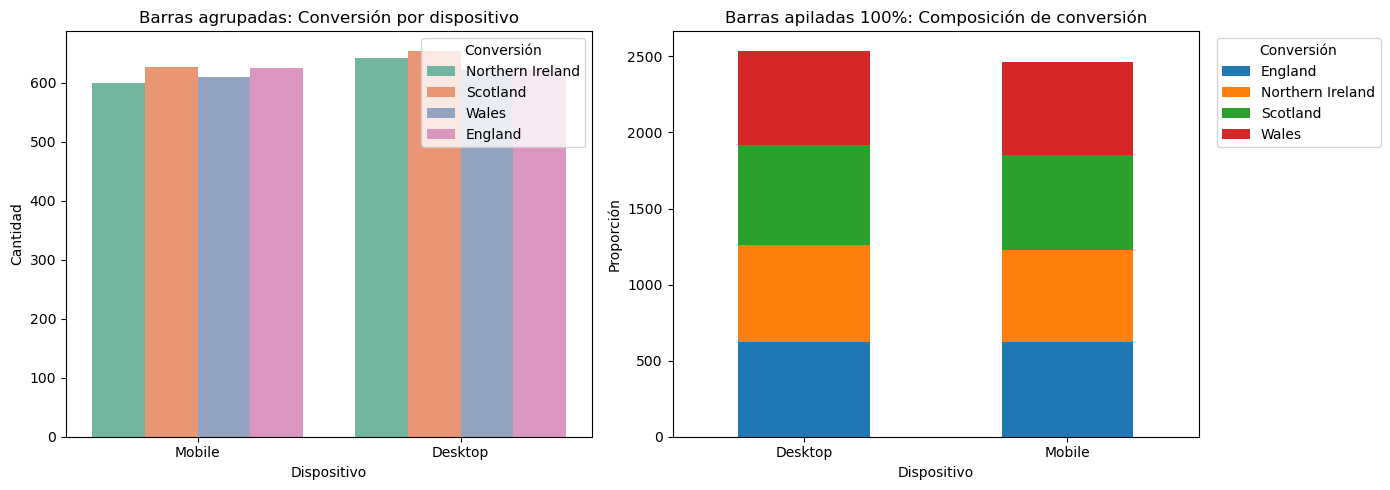

In [25]:
#Visualización grafico agrupado por dispositivo y apilado por conversion

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- 1) Agrupado (Seaborn) ----
sns.countplot(
    data=data,
    x="device",
    hue="location",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Barras agrupadas: Conversión por dispositivo")
axes[0].set_xlabel("Dispositivo")
axes[0].set_ylabel("Cantidad")
axes[0].legend(title="Conversión")

# ---- 2) Apilado 100% (pandas/matplotlib) ----

ct_device.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Barras apiladas 100%: Composición de conversión")
axes[1].set_xlabel("Dispositivo")
axes[1].set_ylabel("Proporción")
axes[1].legend(title="Conversión", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [26]:
# Estimación de la tasa de conversión por dispositivo Chi cuadrado
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(ct_device)
print(f"Chi-cuadrado: {chi2:.4f}, p-valor: {p:.4f}")

# Interpretación del resultado
alpha = 0.05
if p < alpha:
    print("Rechazamos la hipótesis nula: Hay una asociación significativa entre el dispositivo y la conversión.")   
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar una asociación entre el dispositivo y la conversión.")


Chi-cuadrado: 0.9455, p-valor: 0.8144
No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar una asociación entre el dispositivo y la conversión.


In [27]:
#Ahora miremos la fuerza de la asociación con Cramér's V
n = ct_device.values.sum()
min_dim = min(ct_device.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V: {cramers_v:.4f}")

#Interpretacion de Cramér's V
if cramers_v < 0.1:
    print("La asociación es muy débil.")
elif cramers_v < 0.3:
    print("La asociación es débil.")
elif cramers_v < 0.5:
    print("La asociación es moderada.")
elif cramers_v < 0.7:
    print("La asociación es fuerte.")
else:
    print("La asociación es muy fuerte.")

Cramér's V: 0.0138
La asociación es muy débil.


## AHORA TU

Plantea hipotesis de negocio utilizando alguno de los siguientes datasets, determina si es necesario usar una prueba t, z o chi cuadrado:

* [Games A/B](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing)
* [Bike sharing](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data)
* [Student](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

* Plantea las hipotesis nula y alternativa
* Cual es el P-valor y como interpretas el resultado
* Realiza 1 o 2 visualizaciones que apoyen tu conclusión

## Conclusiones finales

- **Tabla de contingencia primero:** ver conteos y proporciones antes de testear.
- **χ² responde “¿hay asociación?”**, no causalidad.
- **p-valor**: evidencia contra H0 (si `p < α`, asociación “significativa”).
- **V de Cramér**: qué tan **fuerte** es la asociación (significativo ≠ importante).
- **Supuestos clave:** independencia + esperados suficientes (muchas esperadas <5 = problema).
- **Si fallan supuestos:** agrupar categorías raras (“Other”) o usar **Fisher** en 2x2 con conteos pequeños.
- **Gráficos:** agrupadas para comparar; apiladas 100% para composición.